# STA for Non-Hermitian PT Symmetric Heisenberg Chain

This notebook numerically studies the Counterdiabatic driving term for Non-Hermitian PT Symmetric Heisenberg chain. The Hamiltonian is given by
$$
H = \sum_{j=1}^{N-1} \sum_{\alpha = \{x,y,z\}}\sigma_j^\alpha \sigma_{j+1}^\alpha + h_1 \alpha_1^z + h_N\sigma_N^z
$$

In [1]:
include("PT_Heisenberg.jl")
using .PT_Heisenberg

include("B2_A2_Transition.jl")
using .B2_A2_Transition

include("AGP_Norm.jl")
using .AGP_Norm

include("KrylovKitAGP.jl")
using .KrylovKitAGP

include("KrylovAGP_Scan.jl")
using .KrylovAGP_Scan

In [2]:
results = KrylovAGP_Scan.scan_krylov_agp_norm(7, 1e-5);
#print_krylov_scan_table(results)

Scanning N=7, χ=1.0e-5,  ξ ∈ [-0.9, -0.4],  n_points=60
Krylov dims: [5, 17, 39, 199]
────────────────────────────────────────────────────────────────────
  ξ=-0.9000 [B2]  exact=4.4134e+01  k=199: 4.3584e+01  (rel_err=1.25e-02)
  ξ=-0.8915 [B2]  exact=4.5480e+01  k=199: 4.4920e+01  (rel_err=1.23e-02)
  ξ=-0.8831 [B2]  exact=4.6878e+01  k=199: 4.6309e+01  (rel_err=1.21e-02)
  ξ=-0.8746 [B2]  exact=4.8330e+01  k=199: 4.7752e+01  (rel_err=1.20e-02)
  ξ=-0.8661 [B2]  exact=4.9838e+01  k=199: 4.9251e+01  (rel_err=1.18e-02)
  ξ=-0.8576 [B2]  exact=5.1405e+01  k=199: 5.0809e+01  (rel_err=1.16e-02)
  ξ=-0.8492 [B2]  exact=5.3033e+01  k=199: 5.2429e+01  (rel_err=1.14e-02)
  ξ=-0.8407 [B2]  exact=5.4725e+01  k=199: 5.4113e+01  (rel_err=1.12e-02)
  ξ=-0.8322 [B2]  exact=5.6484e+01  k=199: 5.5864e+01  (rel_err=1.10e-02)
  ξ=-0.8237 [B2]  exact=5.8312e+01  k=199: 5.7685e+01  (rel_err=1.08e-02)
  ξ=-0.8153 [B2]  exact=6.0215e+01  k=199: 5.9581e+01  (rel_err=1.05e-02)
  ξ=-0.8068 [B2]  exact=6.2194e

(xi = [-0.9, -0.8915254237288136, -0.8830508474576271, -0.8745762711864407, -0.8661016949152542, -0.8576271186440678, -0.8491525423728814, -0.8406779661016949, -0.8322033898305085, -0.823728813559322  …  -0.47627118644067795, -0.46779661016949153, -0.45932203389830506, -0.45084745762711864, -0.4423728813559322, -0.43389830508474575, -0.42542372881355933, -0.41694915254237286, -0.40847457627118644, -0.4], exact = [44.13448348281439, 45.48047050139525, 46.87817960889137, 48.329858050269785, 49.83784228803838, 51.40457097452363, 53.03260275750547, 54.72463994221055, 56.48355921157083, 58.31245062565287  …  606.8151410426153, 525.0263332649791, 514.4297127345782, 523.8132354838124, 539.4840610196335, 557.3291914997973, 576.392890379947, 597.3450137354407, 622.5469344681296, 657.4667755792826], krylov = Dict(5 => [8.832199889170543, 9.12104519074311, 9.42133774063026, 9.733598507056676, 10.058374309049324, 10.396239120845781, 10.747795433677275, 11.11367567566695, 11.494543690237986, 11.891

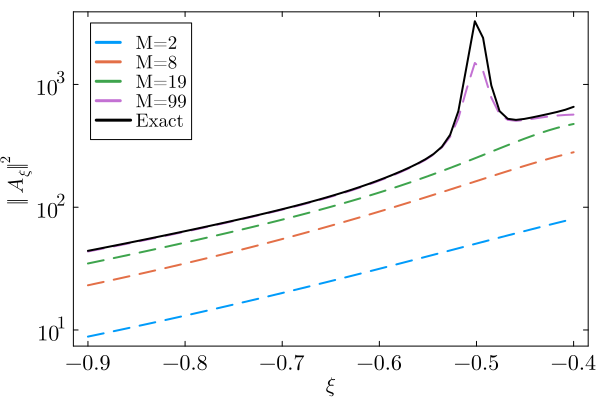

In [11]:
using Plots, LaTeXStrings
p = plot(xlabel=L"ξ", ylabel=L"‖A_ξ‖^2",
         yscale=:log10, legend=:topleft,  frame = :box, grid = false)
for k in results.krylov_dims
    AGP_dim = Int(floor(k/2))
    plot!(p, results.xi, results.krylov[k], label="M=$AGP_dim", linestyle=:dash, linewidth = 2)
end
plot!(p,titlefontsize=18, guidefontsize=16, tickfontsize=14, legendfontsize=12, labelfontsize = 14, fontfamily = "Computer Modern")
plot!(p, results.xi, results.exact, label="Exact", linewidth=2, color=:black)
# vline!(p, [-0.5], linestyle=:dot, color=:red, label = nothing)
# annotate!((0.85,0.1),text(L"ξ = −0.5",10))
#title="Krylov AGP convergence  (N=7, χ=1e-5)",
#savefig(p, "AGP_norm_Heisenberg.pdf")